In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        (os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [16]:
!pip install mne numpy scipy scikit-learn tensorflow pyedflib matplotlib seaborn

In [17]:
import mne
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [18]:
path = "/kaggle/input/datasets/amimulahasanrofik/eeg-in-schizophrenia"  # change if needed

files = os.listdir(path)
print(files)

['h09.edf', 'h07.edf', 's10.edf', 's08.edf', 's06.edf', 'h04.edf', 'MANIFEST.TXT', 'h01.edf', 's01.edf', 'h13.edf', 's09.edf', 's05.edf', 'h10.edf', 's02.edf', 's07.edf', 's14.edf', 's13.edf', 'h14.edf', 's04.edf', 'h12.edf', 'h05.edf', 'h03.edf', 's11.edf', 'h02.edf', 'h08.edf', 'h11.edf', 's03.edf', 'h06.edf', 's12.edf']


In [19]:
def get_label(filename):
    if filename.startswith("h"):
        return 0  # Healthy
    elif filename.startswith("s"):
        return 1  # Schizophrenia

In [20]:
def load_and_preprocess(file_path):

    raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)

    # 1. Bandpass filter (brain signals)
    raw.filter(0.5, 45)

    # 2. Remove power line noise
    raw.notch_filter(50)

    # 3. Standard montage (if channels match)
    try:
        raw.set_montage("standard_1020")
    except:
        pass

    return raw

In [21]:
def create_epochs(raw, window=2.0):

    events = mne.make_fixed_length_events(raw, duration=window)

    epochs = mne.Epochs(
        raw,
        events,
        tmin=0,
        tmax=window,
        baseline=None,
        preload=True,
        verbose=False
    )

    return epochs.get_data()

In [22]:
edf_files = [f for f in files if f.endswith(".edf")]

X = []
y = []

for file in edf_files:

    file_path = os.path.join(path, file)

    raw = load_and_preprocess(file_path)

    epochs = create_epochs(raw)

    label = get_label(file)

    X.append(epochs)
    y.append(np.full(len(epochs), label))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 1651 samples (6.604 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband e

In [24]:
import numpy as np

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Final X shape: (14411, 19, 501)
Final y shape: (14411,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
import tensorflow as tf
from tensorflow.keras import layers

input_layer = tf.keras.Input(shape=(X.shape[1], X.shape[2]))

# CNN (spatial EEG features)
x = layers.Conv1D(64, 3, activation='relu', padding='same')(input_layer)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling1D(2)(x)

# BiLSTM (temporal learning)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

# Attention mechanism
attention = layers.Dense(1, activation='tanh')(x)
attention = layers.Flatten()(attention)
attention = layers.Activation('softmax')(attention)
attention = layers.RepeatVector(128)(attention)
attention = layers.Permute([2,1])(attention)

x = layers.Multiply()([x, attention])

# Feature pooling
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(input_layer, output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-04-13 06:10:29.543764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776060629.730498      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776060629.784316      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776060630.239203      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776060630.239240      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776060630.239243      55 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 19, 501)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 19, 64)    │     96,256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 19, 128)   │     24,704 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 9, 128)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 9, 128)    │     98,816 │ max_pooling1d[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 9, 1)      │        129 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 9)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 9)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 9)    │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 9, 128)    │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9, 128)    │          0 │ bidirectional[0]… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 228,226 (891.51 KB)

 Trainable params: 228,226 (891.51 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16
)

Epoch 1/40


I0000 00:00:1776060657.994036     163 cuda_dnn.cc:529] Loaded cuDNN version 91002


721/721 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.5492 - loss: 0.6914 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 2/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5470 - loss: 0.6891 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 3/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5483 - loss: 0.6887 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 4/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5422 - loss: 0.6898 - val_accuracy: 0.5487 - val_loss: 0.6886
Epoch 5/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5501 - loss: 0.6882 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 6/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5481 - loss: 0.6888 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 7/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5461 - loss: 0.6890 - val_accuracy: 0.5487 - val_loss: 0.6884
Epoch 8/40
721/721 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5468 - loss: 0.6889 - val_accuracy: 0.5487 - 

In [28]:
model.evaluate(X_test, y_test)

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5411 - loss: 0.6899


[0.6883841156959534, 0.5487339496612549]

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


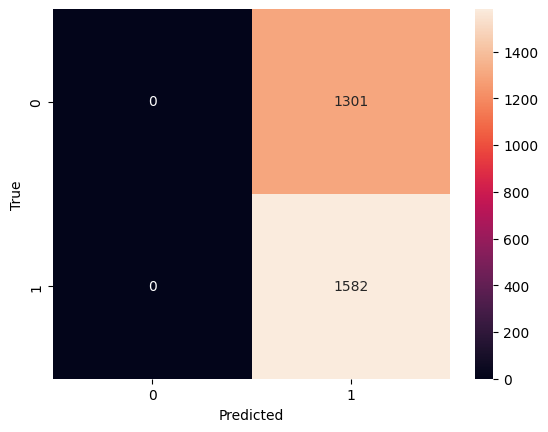

In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1301
           1       0.55      1.00      0.71      1582

    accuracy                           0.55      2883
   macro avg       0.27      0.50      0.35      2883
weighted avg       0.30      0.55      0.39      2883



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


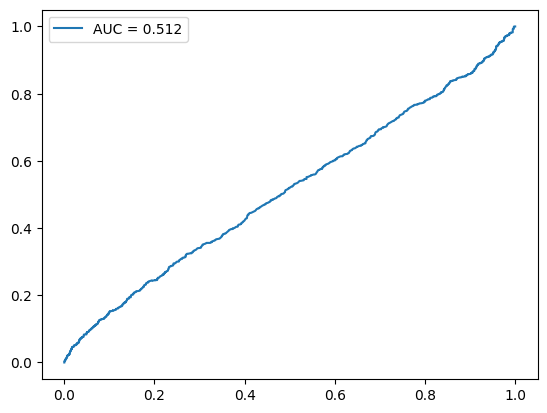

In [31]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, model.predict(X_test))
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.legend()
plt.show()